# Regression Analysis: Simplify complex data relationships

Predicting the taxi fare amounts through a multiple linear regression model.

# Build a multiple linear regression model - multiple linear regression model

**The goal:** build a multiple linear regression model and evaluate the model


## Import and Loading

In [18]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error


In [27]:
# Load dataset
df0 = pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv") 

## Explore data with EDA

In [ ]:
df0.head()

In [ ]:
# Check for missing data and duplicates
df0.isna().any().sum()
df0 = df0.drop_duplicates()

In [ ]:
df0.describe()

In [ ]:
df0.shape, df0.info()

In [ ]:
# Convert datetime columns to datetime
df0['tpep_pickup_datetime'] = pd.to_datetime(df0['tpep_pickup_datetime'])
df0['tpep_dropoff_datetime'] = pd.to_datetime(df0['tpep_dropoff_datetime'])
df0.info()

### Create new column

In [ ]:
# Create `duration` column that is the duration of the ride in minutes
a = df0['tpep_dropoff_datetime'] - df0['tpep_pickup_datetime']
df0['duration'] = a.dt.total_seconds() / 60
df0.head()

### Check for outliers in columns of interest

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(21,21))

sns.boxplot(data = df0, y = 'trip_distance', ax=ax1)
ax1.set_title('Trip Distance')
sns.boxplot(data = df0, y = 'fare_amount', ax=ax2)
ax2.set_title('Fare Amount')
sns.boxplot(data = df0, y = 'duration', ax=ax3)
ax3.set_title('Duration')

fig.show()

In [12]:
#                                                   TRIP_DISTANCE
# Why there are some zeros in 'trip_distance'?

df0[['duration', 'trip_distance', 'fare_amount']].sort_values('trip_distance').head(10)

,duration,trip_distance,fare_amount
22026,0.000000,0.0,10.5
795,0.000000,0.0,8.0
6908,0.066667,0.0,18.0
13561,0.383333,0.0,32.0
12238,0.233333,0.0,2.5
6878,0.050000,0.0,98.5
14372,4.466667,0.0,4.5
20638,0.000000,0.0,2.5
920,0.566667,0.0,2.5
16263,0.350000,0.0,2.5


The distances are captured with a high degree of precision. 
It might be possible for trips to have distances of zero if a passenger summoned a taxi and then changed their mind. 
Are there enough zero values in the data to pose a problem?

In [13]:
df0[df0['trip_distance'] == 0].shape[0]

148

In [14]:
#                                                   FARE_AMOUNT
# Negative fare amount? Why?

df0[df0['fare_amount'] < 0].shape[0]

14

In [15]:
df0[['duration', 'trip_distance', 'fare_amount']].sort_values('fare_amount').head(15)

,duration,trip_distance,fare_amount
12944,1395.683333,0.17,-120.0
11204,2.850000,0.64,-4.5
20698,3.800000,0.70,-4.5
14714,3.166667,0.40,-4.0
17602,3.600000,0.46,-4.0
5448,2.216667,0.25,-3.5
20317,2.250000,0.24,-3.5
8204,2.383333,0.41,-3.5
18565,1.033333,0.10,-3.0
4423,1.333333,0.06,-3.0


Very short trip so either a human mistake or an software mistake 

In [16]:
# So for now values less than $0 set to 0 -- if the model will need more explanation I am going to explore that

df0.loc[df0['fare_amount'] < 0, 'fare_amount'] = 0 

In [18]:
#                                                     DURATION
# Call .describe() for duration outliers
df0['duration'].describe()

count    22699.000000
mean        14.459807
std         11.948480
min        -16.983333
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64

In [19]:
# Impute a 0 for any negative values -- if the model will need more explanation I am going to explore that
df0.loc[df0['duration'] < 0, 'duration'] = 0

In [17]:
#                          SET OUTLIER ABOVE UPPER LIMIT OF THE INTERQUARTILE RANGE TO THE THRESHOLD FOR THE COLUMN OF INTEREST

# Calculate and set upper threshold 
column_list = ['duration', 'trip_distance', 'fare_amount']
for i in column_list:
    Q1 = df0[i].quantile(0.25)
    Q3 = df0[i].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + (6 * IQR)
    print(i, threshold)
    df0.loc[df0[i] > threshold, i] = threshold
    if threshold <= df0[i].max():
        print('OK')
    else:
        print('something wrong in the loop')

duration 88.78333333333333
OK
trip_distance 15.480000000000002
OK
fare_amount 62.5
OK


### Some feature engineering

#### Create `mean_distance` column

Mean distance for each group of trips that share pickup and dropoff points.


In [21]:
# Create `pickup_dropoff` column 

df0[['DOLocationID','PULocationID']] = df0[['DOLocationID','PULocationID']].astype('str')
df0['pickup_dropoff'] = df0[['DOLocationID','PULocationID']].agg(' '.join, axis=1)
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,14.066667,231 100
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,26.500000,43 186
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.200000,236 262
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,97 188
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,16.716667,112 4


In [22]:
grouped = df0.groupby('pickup_dropoff')['trip_distance'].mean()
grouped

pickup_dropoff
1 1        2.433333
1 100     15.480000
1 107     15.480000
1 125     14.670000
1 138     15.480000
            ...    
97 87      3.300000
97 90      4.620000
97 97      1.006667
98 138     8.700000
98 82      4.410000
Name: trip_distance, Length: 4172, dtype: float64

In [23]:
# Convert `grouped` to a dictionary
grouped_dict = grouped.to_dict()

{'1 1': 2.433333333333333,
 '1 100': 15.480000000000002,
 '1 107': 15.480000000000002,
 '1 125': 14.67,
 '1 138': 15.480000000000002,
 '1 151': 15.480000000000002,
 '1 158': 15.480000000000002,
 '1 161': 15.480000000000002,
 '1 162': 15.480000000000002,
 '1 163': 15.480000000000002,
 '1 164': 15.480000000000002,
 '1 166': 15.480000000000002,
 '1 170': 15.480000000000002,
 '1 186': 15.480000000000002,
 '1 230': 15.480000000000002,
 '1 233': 15.480000000000002,
 '1 237': 15.480000000000002,
 '1 246': 15.480000000000002,
 '1 249': 13.65,
 '1 43': 15.480000000000002,
 '1 68': 15.480000000000002,
 '1 79': 15.480000000000002,
 '1 90': 15.480000000000002,
 '10 132': 3.75,
 '100 100': 0.25333333333333335,
 '100 107': 1.436,
 '100 113': 1.9775,
 '100 114': 2.3966666666666665,
 '100 12': 4.0,
 '100 125': 2.1100000000000003,
 '100 13': 3.9799999999999995,
 '100 132': 15.480000000000002,
 '100 137': 1.458,
 '100 138': 9.765,
 '100 141': 2.5149999999999997,
 '100 142': 1.6228571428571428,
 '100 143

In [24]:
# 'mean_distance' column copy of the pickup_dropoff column
df0['mean_distance'] = df0['pickup_dropoff']

# Map `mean_distance` column
df0['mean_distance'] = df0['mean_distance'].map(grouped_dict)

# Check
df0[df0['pickup_dropoff'] == '231 100']

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.0,0.3,16.56,14.066667,231 100,3.521667
4909,96629892,2,2017-11-14 19:22:51,2017-11-14 19:41:33,1,2.79,1,N,100,231,...,13.5,1.0,0.5,4.59,0.0,0.3,19.89,18.700000,231 100,3.521667
16636,48945131,1,2017-06-06 23:04:59,2017-06-06 23:19:48,1,3.70,1,N,100,231,...,14.0,0.5,0.5,2.00,0.0,0.3,17.30,14.816667,231 100,3.521667
18134,50574134,2,2017-06-15 10:05:54,2017-06-15 10:53:26,1,4.10,1,N,100,231,...,28.0,0.0,0.5,0.00,0.0,0.3,28.80,47.533333,231 100,3.521667
19761,7282051,1,2017-02-01 12:28:41,2017-02-01 12:46:00,1,3.10,1,N,100,231,...,13.5,0.0,0.5,2.85,0.0,0.3,17.15,17.316667,231 100,3.521667
20581,49385419,1,2017-06-09 12:50:16,2017-06-09 13:14:55,1,4.10,1,N,100,231,...,19.0,0.0,0.5,0.00,0.0,0.3,19.80,24.650000,231 100,3.521667


#### `mean_duration` column


In [25]:
# Same step of above
grouped = df0.groupby('pickup_dropoff')['duration'].mean()

grouped_dict = grouped.to_dict()

df0['mean_duration'] = df0['pickup_dropoff']

df0['mean_duration'] = df0['mean_duration'].map(grouped_dict)

df0[df0['pickup_dropoff'] == '231 100']

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,14.066667,231 100,3.521667,22.847222
4909,96629892,2,2017-11-14 19:22:51,2017-11-14 19:41:33,1,2.79,1,N,100,231,...,1.0,0.5,4.59,0.0,0.3,19.89,18.700000,231 100,3.521667,22.847222
16636,48945131,1,2017-06-06 23:04:59,2017-06-06 23:19:48,1,3.70,1,N,100,231,...,0.5,0.5,2.00,0.0,0.3,17.30,14.816667,231 100,3.521667,22.847222
18134,50574134,2,2017-06-15 10:05:54,2017-06-15 10:53:26,1,4.10,1,N,100,231,...,0.0,0.5,0.00,0.0,0.3,28.80,47.533333,231 100,3.521667,22.847222
19761,7282051,1,2017-02-01 12:28:41,2017-02-01 12:46:00,1,3.10,1,N,100,231,...,0.0,0.5,2.85,0.0,0.3,17.15,17.316667,231 100,3.521667,22.847222
20581,49385419,1,2017-06-09 12:50:16,2017-06-09 13:14:55,1,4.10,1,N,100,231,...,0.0,0.5,0.00,0.0,0.3,19.80,24.650000,231 100,3.521667,22.847222


#### `day` and `month` columns


In [26]:
# 'day' column
df0['Day'] = df0['tpep_pickup_datetime'].dt.day
 
# Create 'month' column
df0['Month'] = df0['tpep_pickup_datetime'].dt.month

df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,Day,Month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,2.76,0.0,0.3,16.56,14.066667,231 100,3.521667,22.847222,25,3
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,4.00,0.0,0.3,20.80,26.500000,43 186,3.108889,24.470370,11,4
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,1.45,0.0,0.3,8.75,7.200000,236 262,0.881429,7.250000,15,12
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,6.39,0.0,0.3,27.69,30.250000,97 188,3.700000,30.250000,7,5
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.00,0.0,0.3,17.80,16.716667,112 4,4.435000,14.616667,15,4


#### Create `rush_hour` column

Rush hour as:
* Any weekday (not Saturday or Sunday) between 06:00&ndash;10:00 or from 16:00&ndash;20:00

Then set as a binary `rush_hour` column:
* 1 == rush hours
* 0 == not rush hours

In [33]:
# 'rush_hours' column
df0['rush_hours'] = 0
df0['rush_hours'].loc[(df0['tpep_pickup_datetime'].dt.weekday.isin([0,1,2,3,4])) & (df0['tpep_pickup_datetime'].dt.hour.isin([6,7,8,9,16,17,18,19]))] = 1

df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,Day,Month,rush_hours
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,14.066667,231 100,3.521667,22.847222,25,3,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,26.500000,43 186,3.108889,24.470370,11,4,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,7.200000,236 262,0.881429,7.250000,15,12,1
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,30.250000,97 188,3.700000,30.250000,7,5,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,16.716667,112 4,4.435000,14.616667,15,4,0


### Some scatter plot for visualizing data


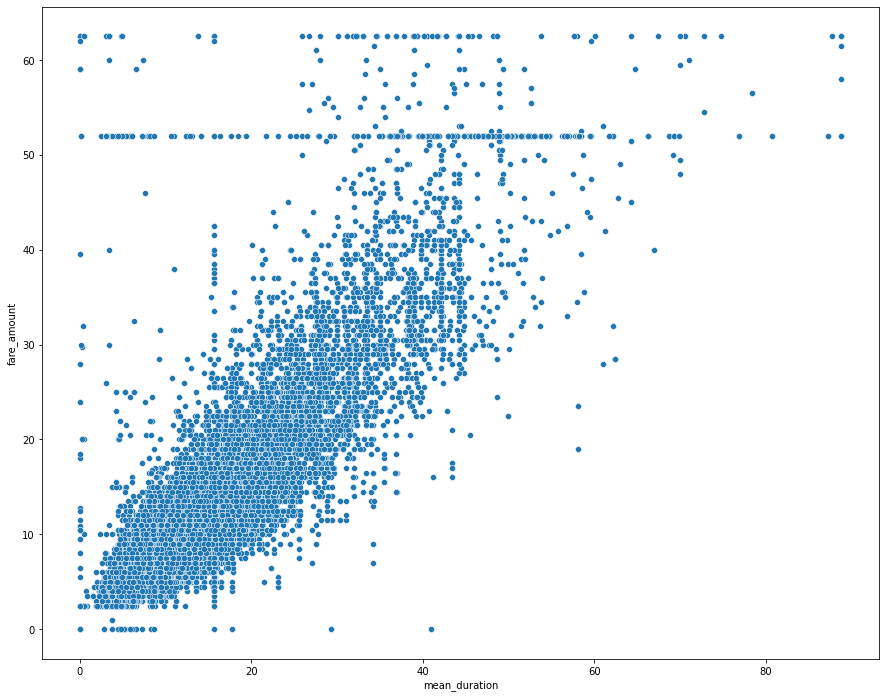

In [35]:
# Relationship between variables of interest

plt.figure(figsize=(15,12))
sns.scatterplot(data=df0, x = 'mean_duration', y = 'fare_amount')
plt.show()

There are some orizontal line. Some is because we set some value to 0 and some to the threshold, but what is the line in the middle?

In [42]:
# Check the orizontal line in the middle 
df0[['fare_amount', 'trip_distance', 'mean_duration', 'duration','rush_hours']][df0['fare_amount'] == 52]

,fare_amount,trip_distance,mean_duration,duration,rush_hours
11,52.0,15.48,40.500000,36.800000,0
110,52.0,15.48,52.941667,66.850000,0
161,52.0,0.23,3.021839,0.966667,0
247,52.0,15.48,47.275000,29.183333,0
379,52.0,15.48,49.833333,29.483333,0
...,...,...,...,...,...
22593,52.0,15.40,61.691667,67.683333,1
22604,52.0,15.48,56.850000,44.716667,0
22620,52.0,15.48,51.493750,36.916667,0
22686,52.0,10.64,80.750000,80.750000,1


In [44]:
pd.set_option('display.max_columns', None)
df0[df0['fare_amount'] == 52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,Day,Month,rush_hours
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,15.48,2,N,236,132,1,52.0,0.0,0.5,14.58,5.54,0.3,72.92,36.800000,132 236,15.480000,40.500000,5,3,0
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,15.48,2,N,132,163,1,52.0,0.0,0.5,0.00,0.00,0.3,52.80,66.850000,163 132,15.480000,52.941667,3,6,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,0.966667,132 132,1.941034,3.021839,11,11,0
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,15.48,2,N,132,79,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,29.183333,79 132,15.480000,47.275000,6,12,0
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,15.48,2,N,132,234,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20,29.483333,234 132,15.480000,49.833333,24,9,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,15.48,2,N,132,48,2,52.0,4.5,0.5,0.00,5.54,0.3,62.84,39.833333,48 132,15.480000,58.246032,28,2,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,15.616667,88 228,4.730000,15.616667,5,6,0
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,15.48,2,N,132,48,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,45.450000,48 132,15.480000,58.246032,3,8,0
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,15.48,2,N,186,132,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,42.850000,132 186,15.480000,42.920000,26,9,0
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,15.48,2,N,132,148,1,52.0,0.0,0.5,5.00,0.00,0.3,57.80,71.583333,148 132,15.480000,46.340476,23,4,0


RateCodeID == 2: Airport.
This is why there are so much equal values.

### Structuring the model

In [46]:
df2 = df0.copy()

# Drop useless column

df2 = df2.drop(['Unnamed: 0', 'tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',
               'pickup_dropoff', 'Day', 'Month'], axis=1)

df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hours       22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.2 MB


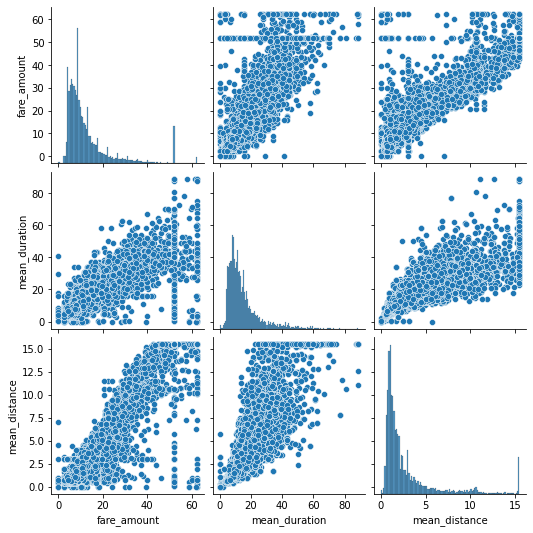

In [48]:
# Visualize pairwise relationships between variables in the data

sns.pairplot(df2[['fare_amount', 'mean_duration', 'mean_distance']])
plt.show()

In [49]:
# Correlation matrix to help determine most correlated variables

df2.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_distance,mean_duration,rush_hours
VendorID,1.000000,0.266463,0.001045,0.002933,0.001876,-0.002874
passenger_count,0.266463,1.000000,0.014942,0.014362,0.015852,-0.022035
fare_amount,0.001045,0.014942,1.000000,0.913404,0.859105,-0.020075
mean_distance,0.002933,0.014362,0.913404,1.000000,0.885492,-0.044230
mean_duration,0.001876,0.015852,0.859105,0.885492,1.000000,-0.021583
rush_hours,-0.002874,-0.022035,-0.020075,-0.044230,-0.021583,1.000000


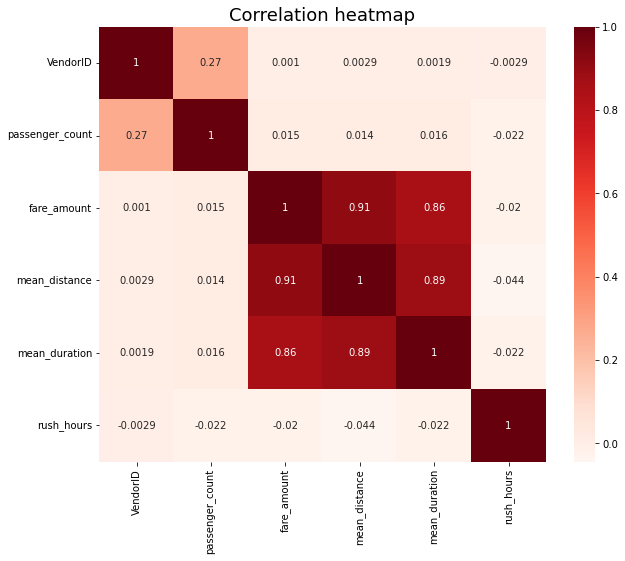

In [50]:
# Better visualization

plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',fontsize=18)
plt.show()

In [54]:
# Splitting the data

X = df2.drop(columns='fare_amount')
Y = df2['fare_amount']

In [55]:
# Conver column as needed for the modeling

X['VendorID'] = X['VendorID'].astype('str')

X = pd.get_dummies(X, drop_first = True)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hours,VendorID_2
0,6,3.521667,22.847222,0,1
1,1,3.108889,24.470370,0,0
2,1,0.881429,7.250000,1,0
3,1,3.700000,30.250000,0,1
4,1,4.435000,14.616667,0,1


In [56]:
# Train and Test set

x_train, x_test, y_train, y_test = tts(X, Y, test_size = 0.2 ,random_state = 0)

### Training set

In [59]:
# Standardize

scaler = StandardScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_train_scaled

In [60]:
# Fit your model to the training data

lr=LinearRegression()
lr.fit(x_train_scaled, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [62]:
# Evaluate the model performance

r_sq = lr.score(x_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(x_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8398896611121379
R^2: 0.8398896611121379
MAE: 2.1956854424004897
MSE: 17.8845720608811
RMSE: 4.2290154954647665


### Test set

In [64]:
# Scale the X_test data

x_test_scaled = scaler.transform(x_test)

In [65]:
# Evaluate the model performance on the testing data

r_sq = lr.score(x_test_scaled, y_test)
print('Coefficient of determination:', r_sq)
y_pred_test = lr.predict(x_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test, y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))


Coefficient of determination: 0.8725082061990184
R^2: 0.8725082061990184
MAE: 2.118708922133368
MSE: 13.864298313196878
RMSE: 3.7234793289606


### Result visualization

In [69]:
# Extract the results

result = pd.DataFrame(data={'actual' : y_test, 'predicted' : y_pred_test.ravel()})
result['residual'] = result['actual'] - result['predicted']
result.head()

,actual,predicted,residual
5818,14.0,12.597750,1.402250
18134,28.0,16.418537,11.581463
4655,5.5,6.497505,-0.997505
7378,15.5,16.980084,-1.480084
13914,9.5,10.434689,-0.934689


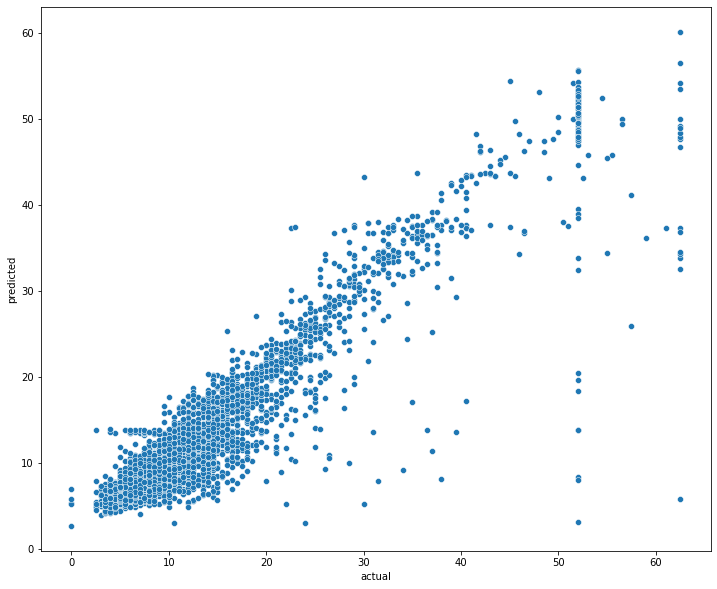

In [75]:
# 

fig, ax = plt.subplots(figsize=(12,10))
sns.scatterplot(data=result, x='actual', y='predicted', ax = ax)
ax.set_title('Actual vs Predicted scatterplot')
ax.set(xlabel = 'Actual', ylabel = 'Predicted')
plt.show()

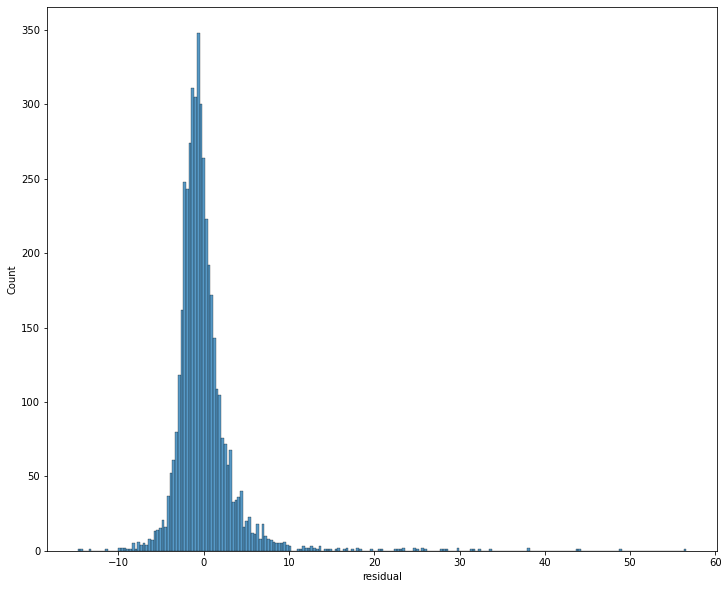

In [80]:
# Visualize the distribution of the `residuals`

fig, ax = plt.subplots(figsize=(12,10))
sns.histplot(result['residual'], ax = ax)
ax.set_title('Residuals distribution')
ax.set(xlabel = 'Residuals', ylabel = 'Count')
plt.show()

In [74]:
# Calculate residual mean
print(f"Mean of the residual = {result['residual'].mean()}")

-0.037130392431823755

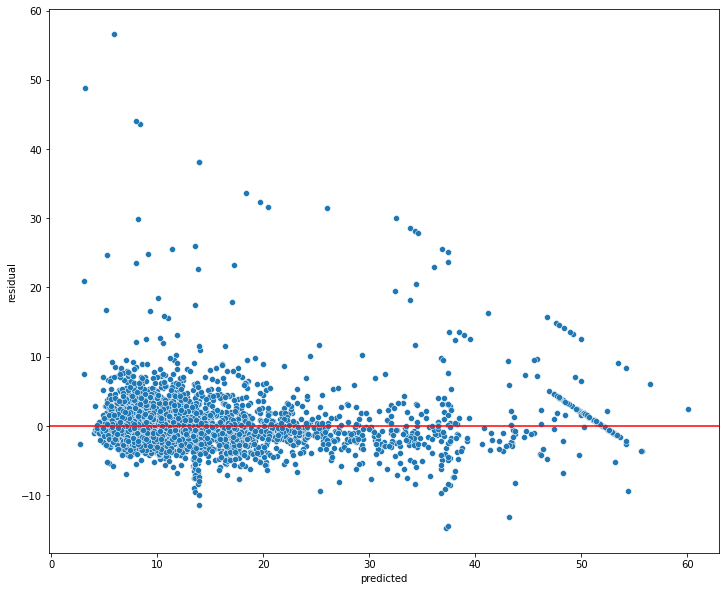

In [78]:
# Distrubution of the residuals

plt.figure(figsize=(12,10))
sns.scatterplot(data=result, x='predicted', y='residual')
plt.title('Distrubution of the residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residual values')
plt.axhline(0, c='red')
plt.show()

In [114]:
#                                            MODEL COEFFICIENT

coef = lr.coef_
coef = coef.reshape(1, -1)
coefficients = pd.DataFrame(coef, columns=X.columns)
coefficients

,passenger_count,mean_distance,mean_duration,rush_hours,VendorID_2
0,0.018418,7.477152,2.424762,0.152908,-0.032391
